In [61]:
#data collection
import pandas as pd

df = pd.read_csv(r"D:\Sentiment_Mental_health_dataset.csv")

print(df.head())

                                           statement                status
0  Anyone else have symptoms much improved after ...               Bipolar
1  I basicaly do not exist, sure feels that way. ...              Suicidal
2  Finding a sense of self It's like one minute I...  Personality_disorder
3  Putting into words what were just tangles in m...               Anxiety
4  Anxiety makes me worry about my public image s...               Anxiety


In [62]:
df.columns = ["text", "label"]

In [63]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26350 entries, 0 to 26349
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    26350 non-null  object
 1   label   26350 non-null  object
dtypes: object(2)
memory usage: 411.8+ KB
None


In [64]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [65]:
print(df.duplicated().sum())

17


In [66]:
df = df.drop_duplicates()

In [67]:
print(df.duplicated().sum())

0


In [68]:
print(df['label'].unique())

['Bipolar' 'Suicidal' 'Personality_disorder' 'Anxiety' 'Depression'
 'Stress' 'Normal']


In [69]:
print(df['label'].value_counts())

label
Suicidal                5592
Anxiety                 4704
Normal                  4574
Depression              4111
Personality_disorder    2810
Bipolar                 2720
Stress                  1822
Name: count, dtype: int64


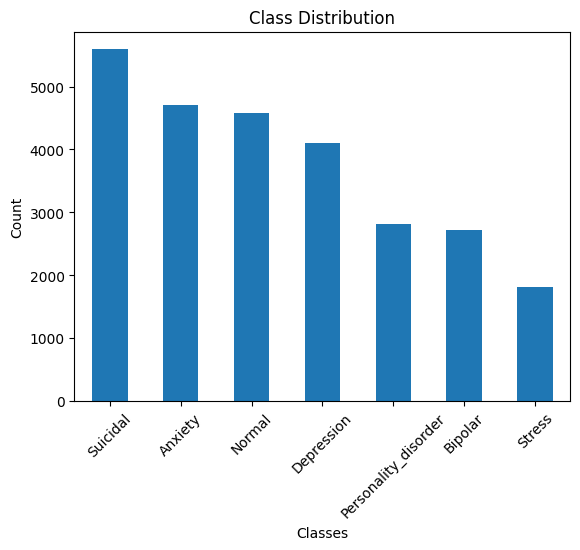

In [70]:
#EDA
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

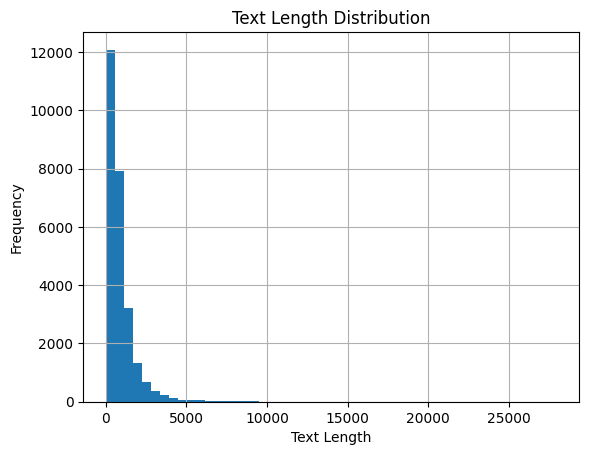

In [71]:
df['text_length'] = df['text'].apply(len)

df['text_length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [72]:
print(df['text_length'].describe())

count    26333.000000
mean       908.390537
std       1144.513479
min          1.000000
25%        338.000000
50%        615.000000
75%       1093.000000
max      27963.000000
Name: text_length, dtype: float64


In [73]:
from collections import Counter
import re

all_text = " ".join(df['text'])

words = re.findall(r'\w+', all_text.lower())

common_words = Counter(words).most_common(20)

print(common_words)

[('i', 313559), ('to', 147045), ('and', 138399), ('the', 100424), ('a', 94186), ('my', 88395), ('it', 71662), ('of', 67077), ('t', 53167), ('that', 52179), ('me', 50235), ('in', 49161), ('m', 45005), ('for', 43333), ('but', 42535), ('is', 41736), ('have', 39514), ('this', 36892), ('with', 34510), ('just', 32186)]


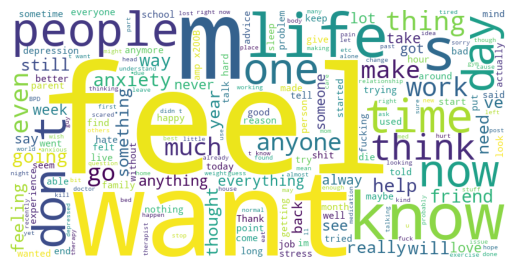

In [74]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [75]:
for label in df['label'].unique():
    subset = df[df['label'] == label]
    print(f"{label}: {len(subset)} samples")

Bipolar: 2720 samples
Suicidal: 5592 samples
Personality_disorder: 2810 samples
Anxiety: 4704 samples
Depression: 4111 samples
Stress: 1822 samples
Normal: 4574 samples


In [76]:
print(df.sample(5))

                                                    text     label  \
22742  How do you feel, I'm kinda fucked up by the pa...  Suicidal   
14381  I’m so done, I’m so tired, I wished I lived in...  Suicidal   
20755  going on a date and having anxiety about it i'...   Anxiety   
20862  My progression and programming, need opinions ...    Normal   
10166  I'm so anxious. This pandemic has made me real...    Stress   

       text_length  
22742          198  
14381          616  
20755          677  
20862         5613  
10166          785  


In [77]:
#Streaming Simulation Loop
df_stream = df.sample(frac=1).reset_index(drop=True).head(200)

In [78]:
import time

def stream_data(data, delay=0.01):
    for i, row in data.iterrows():
        text = row['text']
        label = row['label']
        
        print(f"[{i}] {text}")
        
        time.sleep(delay)

In [79]:
stream_data(df_stream, delay=0.01)

[0] Are you suffering from Trump-Related Stress then this YouTube Playlist called [Kick the Buddy: Hilarious Payback for Trump-Related Stress Relief!](https://www.youtube.com/playlist?list=PL4B0lvOhhpWOO-1YhMI0FqXdKaWIsKIlB) will offer you Relief from that type of Stress in your most Desperate of hours.

For those who don’t know, Trump-related stress refers to the intense emotional distress, anxiety, and mental strain experienced by individuals due to the political presence, actions, and policies of former President Donald Trump. It includes heightened emotional reactions such as anxiety, anger, relentless rumination, and stress linked to Trump’s presidency and its impacts on personal well-being and social dynamics.

# Characteristics of Trump-Related Stress

Trump-related stress is not an officially recognized clinical disorder but is used colloquially to describe the significant psychological and emotional turmoil some experience in response to Trump. It often involves:

* Persistent

In [80]:
def stream_generator(data):
    for _, row in data.iterrows():
        yield row['text'], row['label']

In [81]:
for text, label in stream_generator(df_stream):
    print(text)
    time.sleep(0.01)

Are you suffering from Trump-Related Stress then this YouTube Playlist called [Kick the Buddy: Hilarious Payback for Trump-Related Stress Relief!](https://www.youtube.com/playlist?list=PL4B0lvOhhpWOO-1YhMI0FqXdKaWIsKIlB) will offer you Relief from that type of Stress in your most Desperate of hours.

For those who don’t know, Trump-related stress refers to the intense emotional distress, anxiety, and mental strain experienced by individuals due to the political presence, actions, and policies of former President Donald Trump. It includes heightened emotional reactions such as anxiety, anger, relentless rumination, and stress linked to Trump’s presidency and its impacts on personal well-being and social dynamics.

# Characteristics of Trump-Related Stress

Trump-related stress is not an officially recognized clinical disorder but is used colloquially to describe the significant psychological and emotional turmoil some experience in response to Trump. It often involves:

* Persistent anx

In [82]:
def stream_batches(data, batch_size=10):
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size]

In [83]:
for batch in stream_batches(df_stream, 10):
    print(batch[['text', 'label']])
    time.sleep(0.1)

                                                text       label
0  Are you suffering from Trump-Related Stress th...      Stress
1  My entire life, I have been picked on or treat...    Suicidal
2  Hi, what stress issue are you having now that ...      Stress
3  Friend says he will stop talking to me if I ke...  Depression
4  How to tackle a sedentary lifestyle, according...      Normal
5  I'm struggling and I'm thankful for this space...     Bipolar
6  *** Apologies its lengthy**** they say the cla...      Stress
7  I have a pretty high tolerance to chronic drin...    Suicidal
8  Can someone please tell me how it feels to be ...  Depression
9  Beginner in weight lifting, feel extremely unc...      Normal
                                                 text                 label
10  Passion Flower? Does anyone find passion flowe...               Anxiety
11  Is it normal to flip flop? I've just come home...               Anxiety
12  Thoughts since years and they don't stop comin...    

## Text Preprocessing

In [84]:
import re
import nltk
from nltk.corpus import stopwords ,wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag


def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # remove links
    text = re.sub(r'@\w+', '', text)  # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  Anyone else have symptoms much improved after ...   
1  I basicaly do not exist, sure feels that way. ...   
2  Finding a sense of self It's like one minute I...   
3  Putting into words what were just tangles in m...   
4  Anxiety makes me worry about my public image s...   

                                          clean_text  
0  anyone else have symptoms much improved after ...  
1  i basicaly do not exist sure feels that way no...  
2  finding a sense of self its like one minute im...  
3  putting into words what were just tangles in m...  
4  anxiety makes me worry about my public image s...  


In [85]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_text)

print(df[['clean_text', 'tokens']].head())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                          clean_text  \
0  anyone else have symptoms much improved after ...   
1  i basicaly do not exist sure feels that way no...   
2  finding a sense of self its like one minute im...   
3  putting into words what were just tangles in m...   
4  anxiety makes me worry about my public image s...   

                                              tokens  
0  [anyone, else, symptoms, much, improved, leavi...  
1  [basicaly, exist, sure, feels, way, friends, r...  
2  [finding, sense, self, like, one, minute, im, ...  
3  [putting, words, tangles, brain, chronic, anxi...  
4  [anxiety, makes, worry, public, image, damn, m...  


In [86]:
nltk.download('averaged_perceptron_tagger_eng')
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(tokens):
    pos_tags = pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_text)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [87]:
print(df[['tokens', 'lemmatized']].head())

                                              tokens  \
0  [anyone, else, symptoms, much, improved, leavi...   
1  [basicaly, exist, sure, feels, way, friends, r...   
2  [finding, sense, self, like, one, minute, im, ...   
3  [putting, words, tangles, brain, chronic, anxi...   
4  [anxiety, makes, worry, public, image, damn, m...   

                                          lemmatized  
0  [anyone, else, symptoms, much, improve, leave,...  
1  [basicaly, exist, sure, feel, way, friend, rea...  
2  [find, sense, self, like, one, minute, im, one...  
3  [put, word, tangle, brain, chronic, anxiety, t...  
4  [anxiety, make, worry, public, image, damn, mu...  
